<a href="https://colab.research.google.com/github/Speedycue/Binary-Classification-of-Human-vs.-Non-Human-Faces-using-Deep-Learning/blob/main/Face_Vs_NonFace_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

#uploading Kaggle's API token to import datasets from kaggle
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"speedycue","key":"fea78566b3ed6c76870dd24c7a470716"}'}

In [ ]:
#Creating a directory
!mkdir -p ~/.kaggle
#copying the token into the directory
!cp kaggle.json ~/.kaggle/
#changing the permissions of the file
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
#Importing the dataset
!kaggle datasets download -d houssemlgh/face-vs-non-face-image-dataset-lfw-caltech-256

#Unzip the file
!unzip -q face-vs-non-face-image-dataset-lfw-caltech-256.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/houssemlgh/face-vs-non-face-image-dataset-lfw-caltech-256
License(s): CC-BY-NC-SA-4.0
100% 376M/376M [00:03<00:00, 121MB/s]



In [ ]:
train_dir = 'dataset/train'
test_dir = 'dataset/test'

import os
print(len(os.listdir('dataset/train/human_faces')))
print(len(os.listdir('dataset/train/non_human_faces')))
print(len(os.listdir('dataset/test/human_faces')))
print(len(os.listdir('dataset/test/non_human_faces')))

9513
3901
1892
771


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#Create ImageDataGenerator to use for training set
train_datagen = ImageDataGenerator(
    rescale = 1./255, #Normalisation
    validation_split = 0.2 #Splitting 20% of dataset to use for validation
)

#Loading and preparing the training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary', #Binary classification (Human face or Non-human face)
    subset = 'training' #Specifying 'training' for the training data set
)


#Loading and preparing the validation data
validation_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary', #Binary classification (Human face or Non-human face)
    subset = 'validation' #Specifying 'validation' for the validation data set
)

Found 10732 images belonging to 2 classes.
Found 2682 images belonging to 2 classes.


In [ ]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, UpSampling2D, Dropout

In [ ]:
#Creating CNN model - Custom

model = Sequential([])

model.add(Conv2D(32, (3,3), padding='valid', activation='relu', input_shape=(256,256,3))) #32 filters
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128, (3,3), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu')) #Feature reduction
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid')) #Output layer for binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'binary_crossentropy', #Binary classification
    metrics = ['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

#Defining a path to save the best verison of the model in case the Runtime disconnects
checkpoint_path = "/content/drive/MyDrive/face_model_checkpoint.keras"

checkpoint = ModelCheckpoint(
    filepath = checkpoint_path,
    save_weights_only = False, #Saves the whole model
    monitor = 'val_accuracy', #It will only save if hte 'validation accuracy' improves
    mode = 'max',
    save_best_only = True, #Overwrites the file only when it finds a better version
    verbose = 1
)

In [ ]:
history = model.fit(
    train_data,
    epochs = 10,
    callbacks = [checkpoint],
    validation_data = validation_data
)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9152 - loss: 0.2186
Epoch 1: val_accuracy improved from None to 0.99590, saving model to /content/drive/MyDrive/face_model_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/face_model_checkpoint.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 56s 139ms/step - accuracy: 0.9662 - loss: 0.0890 - val_accuracy: 0.9959 - val_loss: 0.0187
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9937 - loss: 0.0189
Epoch 2: val_accuracy did not improve from 0.99590
336/336 ━━━━━━━━━━━━━━━━━━━━ 31s 91ms/step - accuracy: 0.9932 - loss: 0.0205 - val_accuracy: 0.9940 - val_loss: 0.0279
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9931 - loss: 0.0192
Epoch 3: val_accuracy improved from 0.99590 to 0.99739, saving model to /content/drive/MyDrive/face_model_checkpoint.keras

Epoch 3: finished saving model to /content/drive/MyDrive/face_model_checkpoint.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 30s 8

<function matplotlib.pyplot.show(close=None, block=None)>

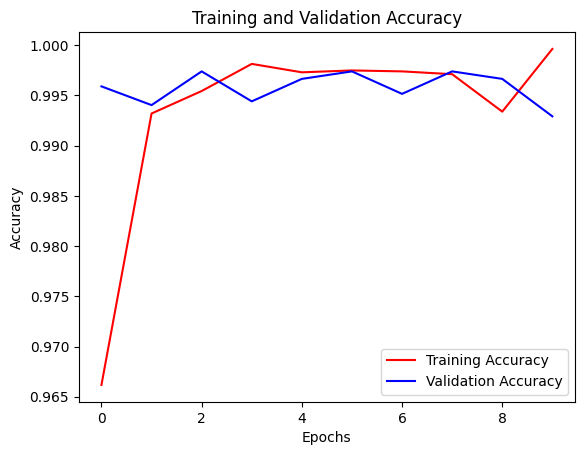

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show

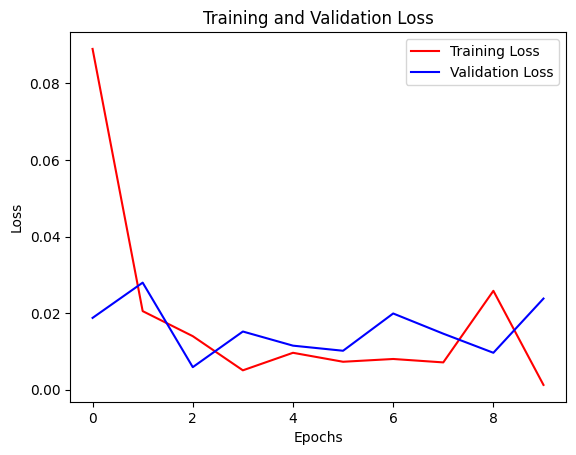

In [ ]:
plt.plot(history.history['loss'], color = 'red', label = 'Training Loss')
plt.plot(history.history['val_loss'], color = 'blue', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(
    rescale = 1./255
)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = False
)

Found 2663 images belonging to 2 classes.


In [ ]:
#Predicting the test data
predictions = model.predict(test_data)

84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(true_labels, predicted_labels)

#printing the confusion matrix
print("Confusion Matrix:")
print(cm)

#Printing the classification report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[1885    7]
 [  16  755]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1892
           1       0.99      0.98      0.98       771

    accuracy                           0.99      2663
   macro avg       0.99      0.99      0.99      2663
weighted avg       0.99      0.99      0.99      2663



The model is performing well on training data but not so well on test data. Hence there is overfitting which can be resolved by applying BatchNormalization and Dropout techniques


In [ ]:
#Create CNN model

model = Sequential()

#Layer 1: 32 Filters
model.add(Conv2D(32,kernel_size=(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

#Layer 2: 64 Filters
model.add(Conv2D(64,kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

#Layer 3: 128 Filters
model.add(Conv2D(128,kernel_size=(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

#Flattening the data into a 1D array for the dense layers
model.add(Flatten())

#Fully connected layers with dropout
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

#Output layer for binary classification (Sigmoid)
model.add(Dense(1, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from keras.optimizers import Adam
model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'binary_crossentropy', #Binary classification
    metrics = ['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs = 10,
    callbacks = [checkpoint],
    validation_data = validation_data
)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9223 - loss: 2.2440
Epoch 1: val_accuracy did not improve from 0.99888
336/336 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.9535 - loss: 1.6935 - val_accuracy: 0.9545 - val_loss: 0.3855
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9827 - loss: 0.5679
Epoch 2: val_accuracy did not improve from 0.99888
336/336 ━━━━━━━━━━━━━━━━━━━━ 33s 98ms/step - accuracy: 0.9831 - loss: 0.5488 - val_accuracy: 0.9258 - val_loss: 3.1763
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9869 - loss: 0.3554
Epoch 3: val_accuracy did not improve from 0.99888
336/336 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step - accuracy: 0.9893 - loss: 0.2164 - val_accuracy: 0.8695 - val_loss: 3.8724
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9896 - loss: 0.2879
Epoch 4: val_accuracy did not improve from 0.99888
336/336 ━━━━━━━━━━━━━━━━━━━━ 33s 99ms/step - accuracy: 0.9906 - loss: 0.2708 - val_accurac

In [ ]:
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size = (256,256),
    batch_size = 32,
    class_mode = 'binary',
    shuffle = False
)

Found 2663 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))

Confusion Matrix:
[[1850   42]
 [   1  770]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1892
           1       0.95      1.00      0.97       771

    accuracy                           0.98      2663
   macro avg       0.97      0.99      0.98      2663
weighted avg       0.98      0.98      0.98      2663



In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten

resnet_model = Sequential()
pretrained_model= tf.keras.applications.ResNet50(
    include_top=False,    #Excludes final top layer of pre-trained model
    input_shape=(256,256,3),
    pooling = 'max',
    classes = 2,
    weights = 'imagenet'
)

for layer in pretrained_model.layers:
  layer.trainable = False

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(1, activation='sigmoid'))

In [ ]:
from keras.optimizers import Adam
resnet_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = 'binary_crossentropy', #Binary classification
    metrics = ['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

pretrained_path = "/content/drive/MyDrive/pretrained_face_model_checkpoint.keras"

CustomCheckpoint = ModelCheckpoint(
    filepath = pretrained_path,
    monitor = 'val_accuracy', #It will only save if hte 'validation accuracy' improves
    mode = 'max',
    save_best_only = True, #Overwrites the file only when it finds a better version
    verbose = 1
)

In [ ]:
history = resnet_model.fit(
    train_data,
    epochs = 10,
    callbacks=[CustomCheckpoint],
    validation_data = validation_data
)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8501 - loss: 0.8056
Epoch 1: val_accuracy improved from None to 0.85198, saving model to /content/drive/MyDrive/pretrained_face_model_checkpoint.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pretrained_face_model_checkpoint.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 66s 163ms/step - accuracy: 0.9124 - loss: 0.3317 - val_accuracy: 0.8520 - val_loss: 0.5780
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9500 - loss: 0.1296
Epoch 2: val_accuracy improved from 0.85198 to 0.95973, saving model to /content/drive/MyDrive/pretrained_face_model_checkpoint.keras

Epoch 2: finished saving model to /content/drive/MyDrive/pretrained_face_model_checkpoint.keras
336/336 ━━━━━━━━━━━━━━━━━━━━ 45s 133ms/step - accuracy: 0.9590 - loss: 0.1106 - val_accuracy: 0.9597 - val_loss: 0.0919
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9716 - loss: 0.0746
Epoch 3: val_accuracy improved from 0

In [ ]:
predictions = resnet_model.predict(test_data)

84/84 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

true_labels = test_data.classes
predicted_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")  #Printing confusion matrix
print(cm)

print("\nClassification Report:") #Printing classification report
print(classification_report(true_labels, predicted_labels))


Confusion Matrix:
[[1872   20]
 [  22  749]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1892
           1       0.97      0.97      0.97       771

    accuracy                           0.98      2663
   macro avg       0.98      0.98      0.98      2663
weighted avg       0.98      0.98      0.98      2663

